In [139]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder 

In [188]:
dataset = pd.read_csv('car_price.csv')

In [189]:
import os
os.listdir()

['.ipynb_checkpoints',
 'car_price.csv',
 'Untitled Folder',
 'Untitled.ipynb',
 'untitled.txt']

In [203]:
dataset.head(2)

,car_name,kms_driven,fuel_type,transmission,ownership,manufacture,engine,Seats,car_prices_in_rupee
0,743,86226,1,1,1,2017,1956,5,10.03
1,1444,13248,4,0,1,2021,1330,5,12.83


In [191]:
dataset.isnull().sum()

Unnamed: 0             0
car_name               0
kms_driven             0
fuel_type              0
transmission           0
ownership              0
manufacture            0
engine                 0
Seats                  0
car_prices_in_rupee    0
dtype: int64

In [201]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5512 entries, 0 to 5511
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Unnamed: 0           5512 non-null   int64 
 1   car_name             5512 non-null   int64 
 2   kms_driven           5512 non-null   int64 
 3   fuel_type            5512 non-null   int64 
 4   transmission         5512 non-null   int64 
 5   ownership            5512 non-null   object
 6   manufacture          5512 non-null   int64 
 7   engine               5512 non-null   int64 
 8   Seats                5512 non-null   int64 
 9   car_prices_in_rupee  5512 non-null   object
dtypes: int64(8), object(2)
memory usage: 430.8+ KB


In [193]:
car_name_le = LabelEncoder()
dataset['car_name'] = car_name_le.fit_transform(dataset["car_name"])

In [194]:
dataset['fuel_type'].unique()

array(['Diesel', 'Petrol', 'Cng', 'Electric', 'Lpg'], dtype=object)

In [195]:
fuel_type_le = LabelEncoder()
dataset['fuel_type'] = fuel_type_le.fit_transform(dataset["fuel_type"])

In [196]:
transmission_le = LabelEncoder()
dataset['transmission'] = transmission_le.fit_transform(dataset["transmission"])

In [197]:
dataset['kms_driven'] = dataset['kms_driven'].str.replace('[^0-9]','',regex=True).astype(int)

In [198]:
dataset['engine'] = dataset['engine'].str.replace('cc','').astype(int)

In [199]:
dataset['Seats'] = dataset['Seats'].str.replace('Seats','').astype(int)

In [202]:
# Clean ownership
dataset['ownership'] = dataset['ownership'].str.extract('(\d)').astype(int)

# Extract only numbers from price column
dataset['car_prices_in_rupee'] = dataset['car_prices_in_rupee'].str.extract('(\d+\.?\d*)').astype(float)

# Drop useless column
dataset.drop('Unnamed: 0', axis=1, inplace=True)

In [204]:
dataset.head(3)

,car_name,kms_driven,fuel_type,transmission,ownership,manufacture,engine,Seats,car_prices_in_rupee
0,743,86226,1,1,1,2017,1956,5,10.03
1,1444,13248,4,0,1,2021,1330,5,12.83
2,1706,60343,4,0,1,2016,2494,5,16.40


In [207]:
input_data = dataset.iloc[:,:-1]
output_data = dataset['car_prices_in_rupee']

In [209]:
from sklearn.preprocessing import StandardScaler

In [213]:
ss = StandardScaler()
input_data = pd.DataFrame(ss.fit_transform(input_data),columns=input_data.columns)

In [222]:
from sklearn.model_selection import train_test_split

In [223]:
x_train,x_test,y_train,y_test = train_test_split(input_data,output_data,test_size=0.2,random_state=42)

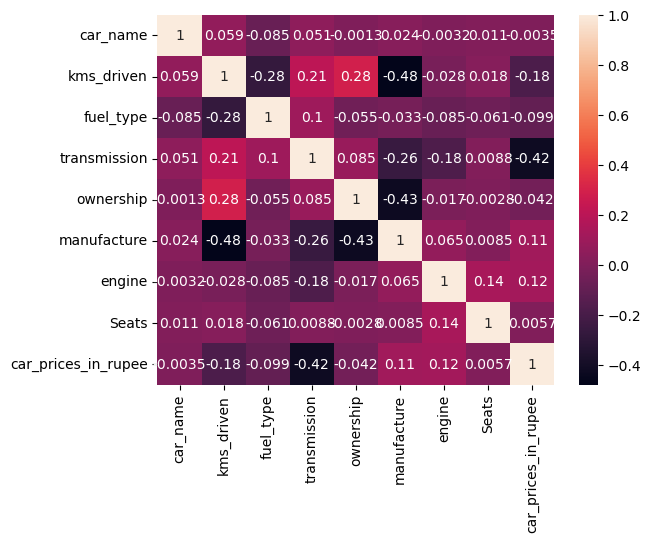

In [226]:
sns.heatmap(data=dataset.corr(),annot=True)
plt.show()

In [224]:
from sklearn.linear_model import LinearRegression , Lasso , Ridge, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

In [241]:
from sklearn.metrics import mean_squared_error , mean_absolute_error

In [225]:
lr = LinearRegression()
lr.fit(x_train,y_train)
lr.score(x_train,y_train)*100 , lr.score(x_test,y_test)*100

(19.345097886934536, 23.51523109359296)

In [242]:
mean_squared_error(y_test,lr.predict(x_test)) , mean_absolute_error(y_test,lr.predict(x_test))

(203.00375254739959, 8.17019204598119)

In [232]:
lr1 = Lasso(alpha=0.5)
lr1.fit(x_train,y_train)
lr1.score(x_train,y_train)*100 , lr1.score(x_test,y_test)*100

(18.60794462417057, 22.9120195079185)

In [236]:
lr2 = Ridge(alpha=2)
lr2.fit(x_train,y_train)
lr2.score(x_train,y_train)*100 , lr2.score(x_test,y_test)*100

(19.345093081901975, 23.514437806013213)

In [237]:
lr3 = ElasticNet(alpha=0.5)
lr3.fit(x_train,y_train)
lr3.score(x_train,y_train)*100 , lr3.score(x_test,y_test)*100

(18.03728684537711, 21.7695678473953)

In [238]:
dt = DecisionTreeRegressor()
dt.fit(x_train,y_train)
dt.score(x_train,y_train)*100 , dt.score(x_test,y_test)*100

(99.9999980679926, 33.575783611278084)

In [244]:
mean_squared_error(y_test,dt.predict(x_test)) , mean_absolute_error(y_test,dt.predict(x_test))

(176.3013130553037, 4.197579329102449)

In [245]:
rf = RandomForestRegressor()
rf.fit(x_train,y_train)
rf.score(x_train,y_train)*100 , rf.score(x_test,y_test)*100

(94.48553484790291, 61.529437796822606)

In [246]:
mean_squared_error(y_test,rf.predict(x_test)) , mean_absolute_error(y_test,rf.predict(x_test))

(102.10749932983009, 3.903842133575098)

In [247]:
y_test

5013     6.31
4462     3.08
79       4.65
5343     2.60
1223     7.25
        ...  
4602     1.99
3968     2.30
1001    11.21
3203     5.02
4322     3.85
Name: car_prices_in_rupee, Length: 1103, dtype: float64

In [248]:
x_test

,car_name,kms_driven,fuel_type,transmission,ownership,manufacture,engine,Seats
5013,0.608336,1.114979,-1.068243,0.625473,0.822432,0.393228,-0.922545,-0.348225
4462,0.941438,0.401242,0.918538,-1.598790,2.244850,0.393228,-1.568310,-0.348225
79,-0.433576,-0.961079,0.918538,0.625473,-0.599986,-0.370594,-0.578943,-0.348225
5343,-1.256648,2.074269,-1.068243,0.625473,-0.599986,-0.625201,1.116621,2.429515
1223,0.346890,-0.459171,-1.730503,0.625473,-0.599986,0.138621,-0.230161,-0.348225
...,...,...,...,...,...,...,...,...
4602,0.106747,0.771435,0.918538,0.625473,-0.599986,-0.115987,-0.813767,-0.348225
3968,0.931755,-0.046699,-1.068243,0.625473,-0.599986,-1.134416,-0.770601,-0.348225
1001,0.800064,0.532001,-1.068243,-1.598790,0.822432,-0.879809,-0.235341,-0.348225
3203,1.092496,-0.178485,0.918538,0.625473,-0.599986,0.902442,1.116621,-0.348225


In [269]:
#rf.predict([[0.608336,1.114979,-1.068243,0.625473,0.822432,0.393228,-0.922545,-0.348225]])

In [254]:
new_data =  pd.DataFrame([['Jeep Compass 2.0 Longitude Option BSIV',86226,'Diesel','Manual',1,2017,1956,5]],columns=x_train.columns)


In [267]:
new_data

,car_name,kms_driven,fuel_type,transmission,ownership,manufacture,engine,Seats
0,743.0,86226.0,1.0,1.0,1.0,2017.0,1956.0,5.0


In [268]:
rf.predict(new_data)

array([11.317])

In [256]:
 new_data['car_name']= car_name_le.transform(new_data["car_name"])

In [260]:
# new_data['fuel_type']= fuel_type_le.transform(new_data["fuel_type"])

In [261]:
 new_data['transmission']= transmission_le.transform(new_data["transmission"])

In [266]:
new_data = pd.DataFrame(ss.transform(new_data),columns = new_data.columns)